# Correlated Random Sequences

**Scott Prahl**

These routines generate *correlated Gaussian noise*, not speckle.

This distinction matters and is easy to get wrong.  `create_correlated` and
`create_correlated` return normally distributed values whose
**autocorrelation** has the named shape.  The speckle generators
(`create_exponential` and friends, covered in the next notebook) return
**irradiance**, which is exponentially distributed and never negative.  The
word "exponential" means something different in each case:

| routine | values are | the name refers to |
| :-- | :-- | :-- |
| `create_correlated` | Gaussian | the autocorrelation, $\exp(-x/c_l)$ |
| `create_correlated` | Gaussian | the autocorrelation, $\exp(-x^2/c_l^2)$ |
| `create_exponential` | exponential | the irradiance distribution |

Sequences like these model rough surface profiles, phase screens, and
correlated detector signals -- the *inputs* to a scattering calculation rather
than the speckle that comes out of one.

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import numpy as np
import matplotlib.pyplot as plt

if sys.platform == "emscripten":
    import piplite

    await piplite.install("pyspeckle")

import pyspeckle

# fix the seed so re-running this notebook reproduces the same figures
np.random.seed(0)

## Uniform random numbers

Start with the uncorrelated case, so there is something to compare against.
`np.random.random` draws independently from a flat distribution on $[0,1)$,
with mean $1/2$ and standard deviation $1/\sqrt{12}$.

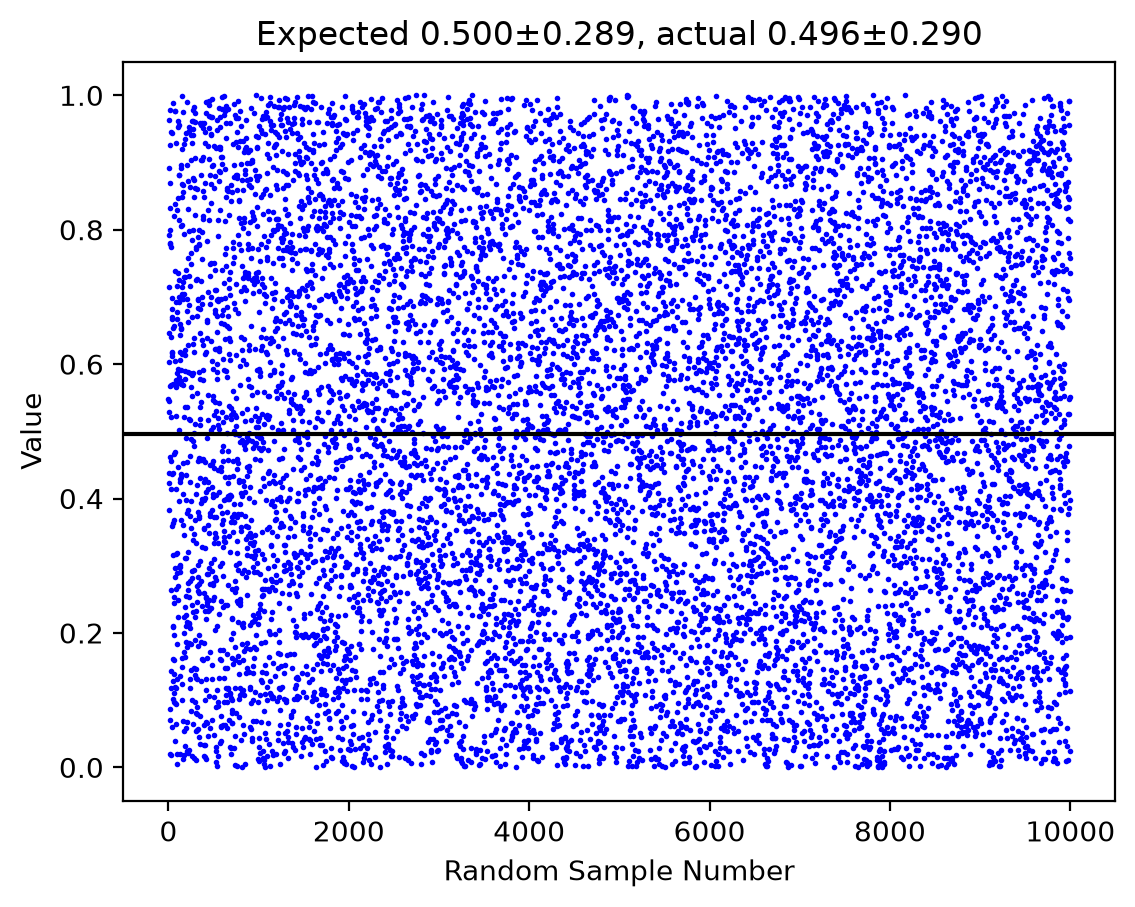

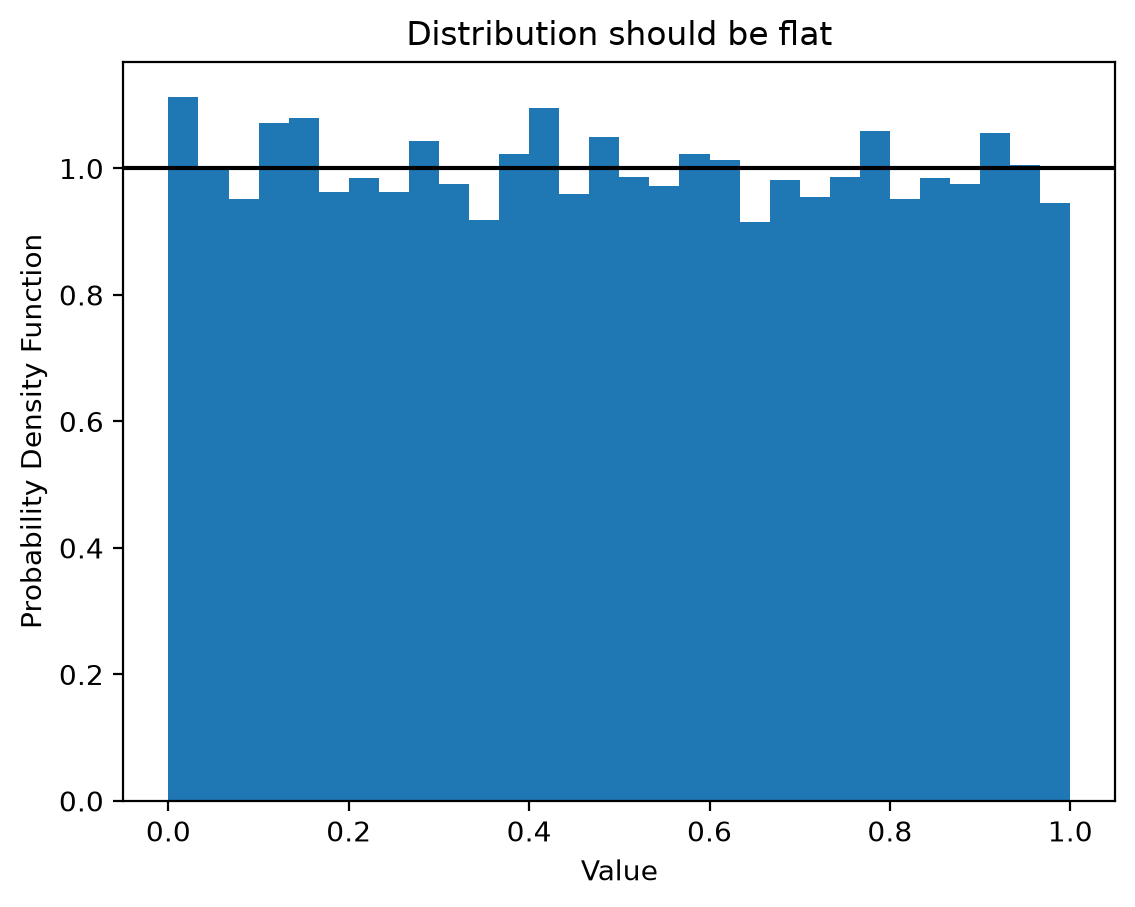

In [2]:
target_length = 10000
target_ave = 1 / 2
target_std = 1 / np.sqrt(12)
y = np.random.random(target_length)

plt.plot(y, "ob", markersize=1)
plt.axhline(np.mean(y), color="black")
plt.title("Expected %.3f±%.3f, actual %.3f±%.3f" % (target_ave, target_std, np.mean(y), np.std(y)))
plt.xlabel("Random Sample Number")
plt.ylabel("Value")
plt.show()

plt.hist(y, 30, density=True)
plt.axhline(1.0, color="black")
plt.xlabel("Value")
plt.ylabel("Probability Density Function")
plt.title("Distribution should be flat")
plt.show()

## Exponential autocorrelation

`create_correlated(M, mean, stdev, cl, correlation="exponential")` returns a sequence with a chosen mean
and standard deviation whose autocorrelation decays as $\exp(-x/c_l)$.

Neighbouring samples are no longer independent, so the trace wanders instead of
jumping.  The *distribution* of values is still Gaussian.

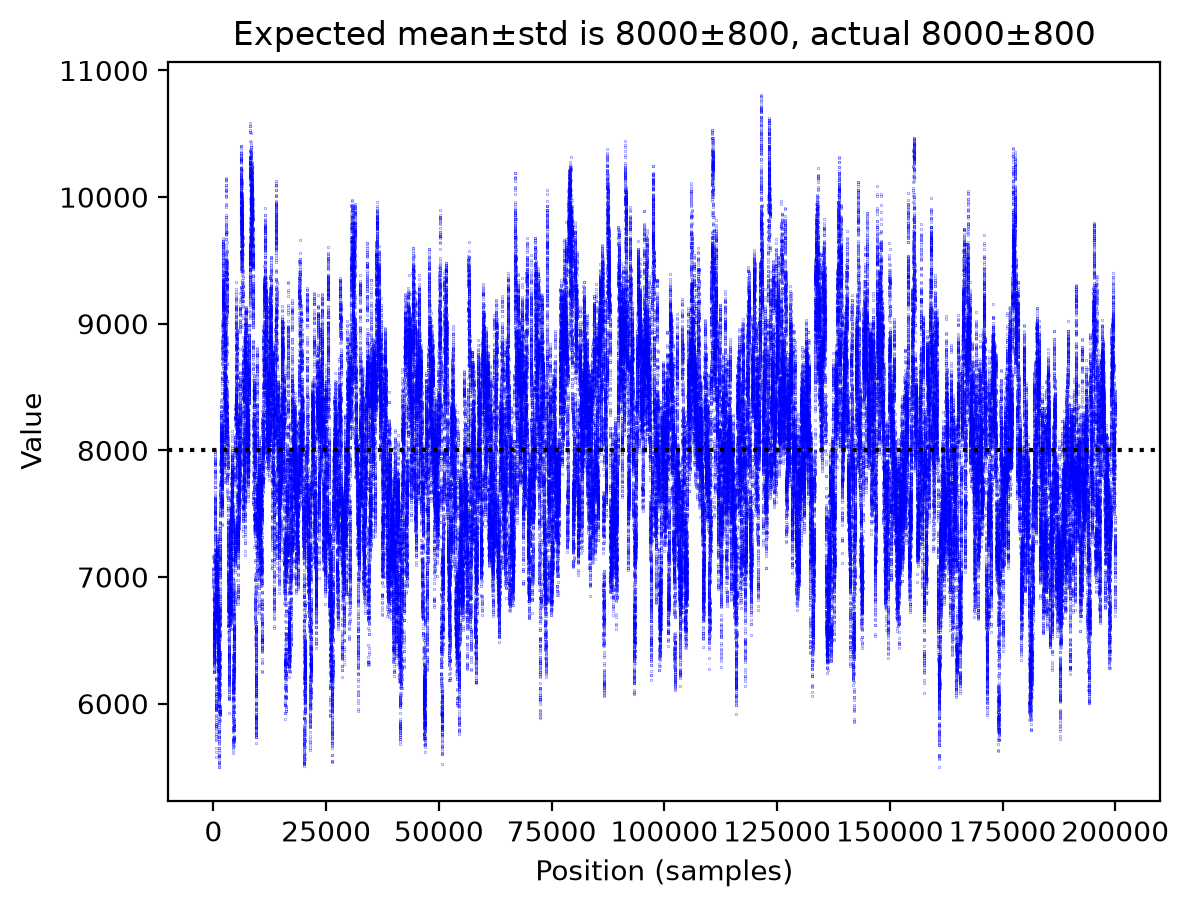

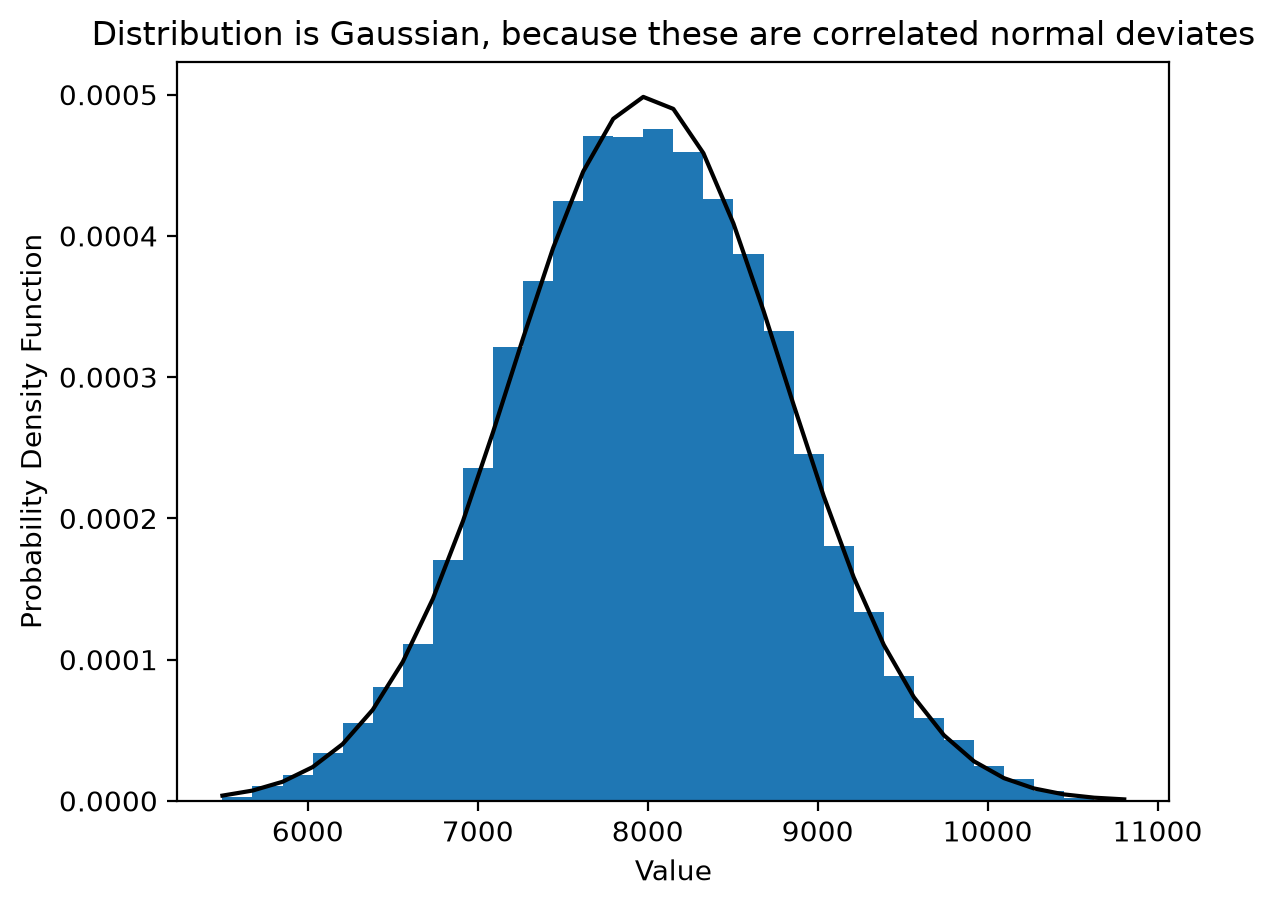

In [3]:
target_length = 200000  # number of samples
correlation_length = 300  # correlation length in samples
target_ave = 8000  # target average value
target_std = 800  # target standard deviation

y = pyspeckle.create_correlated(target_length, target_ave, target_std, correlation_length, correlation="exponential")

plt.plot(y, "ob", markersize=0.1)
plt.axhline(np.mean(y), ls=":", color="black")
plt.title("Expected mean±std is %.0f±%0.f, actual %.0f±%.0f" % (target_ave, target_std, np.mean(y), np.std(y)))
plt.xlabel("Position (samples)")
plt.ylabel("Value")
plt.show()

count, bins, ignored = plt.hist(y, 30, density=True)
plt.plot(bins, 1 / (target_std * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((bins - target_ave) / target_std) ** 2), "k")
plt.xlabel("Value")
plt.ylabel("Probability Density Function")
plt.title("Distribution is Gaussian, because these are correlated normal deviates")
plt.show()

The mean, the standard deviation, and the correlation length are set
independently.  Here four sequences share a standard deviation of 100 but have
different means and correlation lengths; longer correlation lengths give
visibly smoother traces.

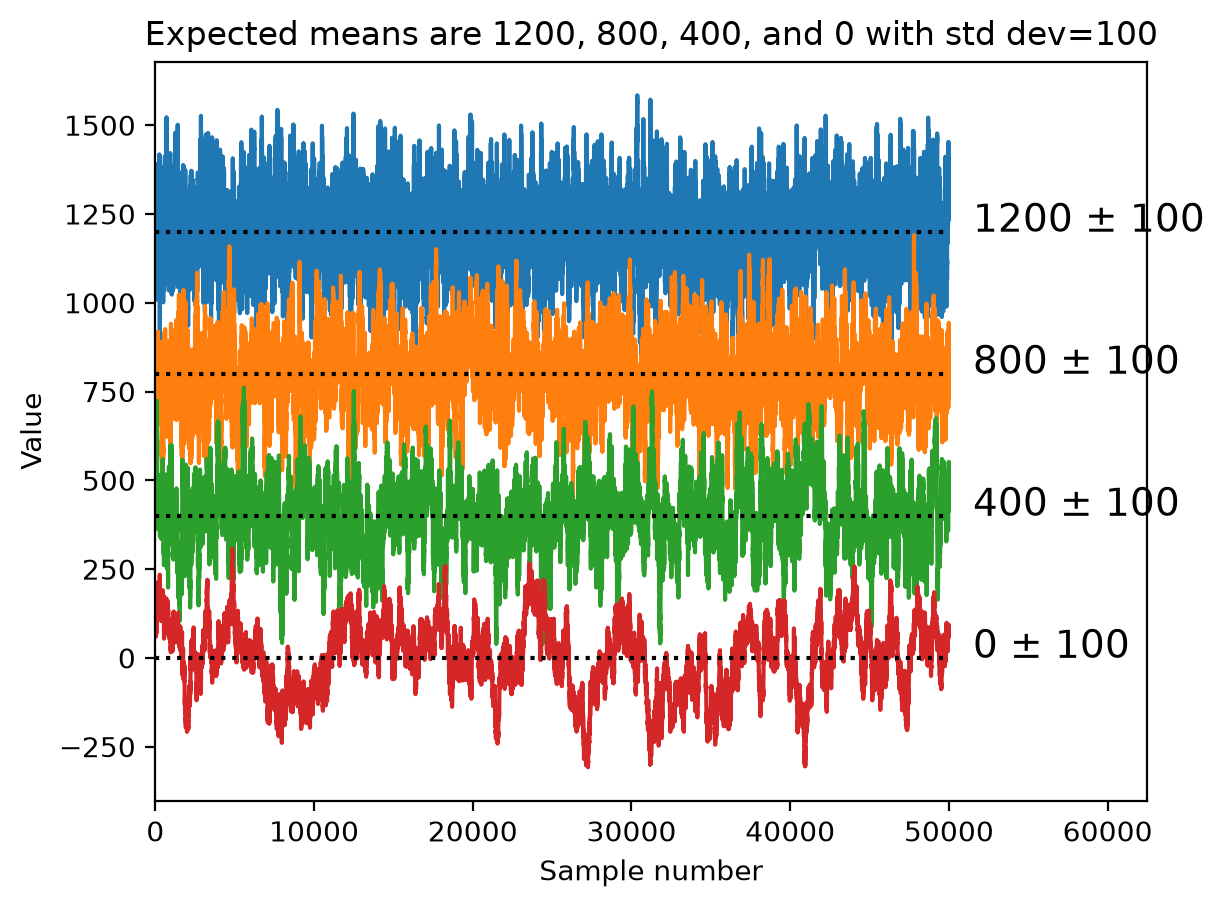

In [4]:
target_length = 50000
target_std = 100

for target_ave, cl in [(1200, 20), (800, 50), (400, 100), (0, 500)]:
    y = pyspeckle.create_correlated(target_length, target_ave, target_std, cl, correlation="exponential")
    plt.text(target_length, np.mean(y), "  %.0f ± %.0f" % (np.mean(y), np.std(y)), fontsize=14)
    plt.plot(y)
    plt.plot([0, target_length], [target_ave, target_ave], ":k")

plt.xlim(0, target_length * 1.25)
plt.title("Expected means are 1200, 800, 400, and 0 with std dev=%.0f" % target_std)
plt.xlabel("Sample number")
plt.ylabel("Value")
plt.show()

## Checking the autocorrelation

The defining property is the autocorrelation, so it is worth verifying.
`pyspeckle.autocorrelation` subtracts the mean, normalizes the peak to one, and
returns the right-hand half of the symmetric function.

Because the shape is known analytically, this doubles as a test of the
autocorrelation routine itself.

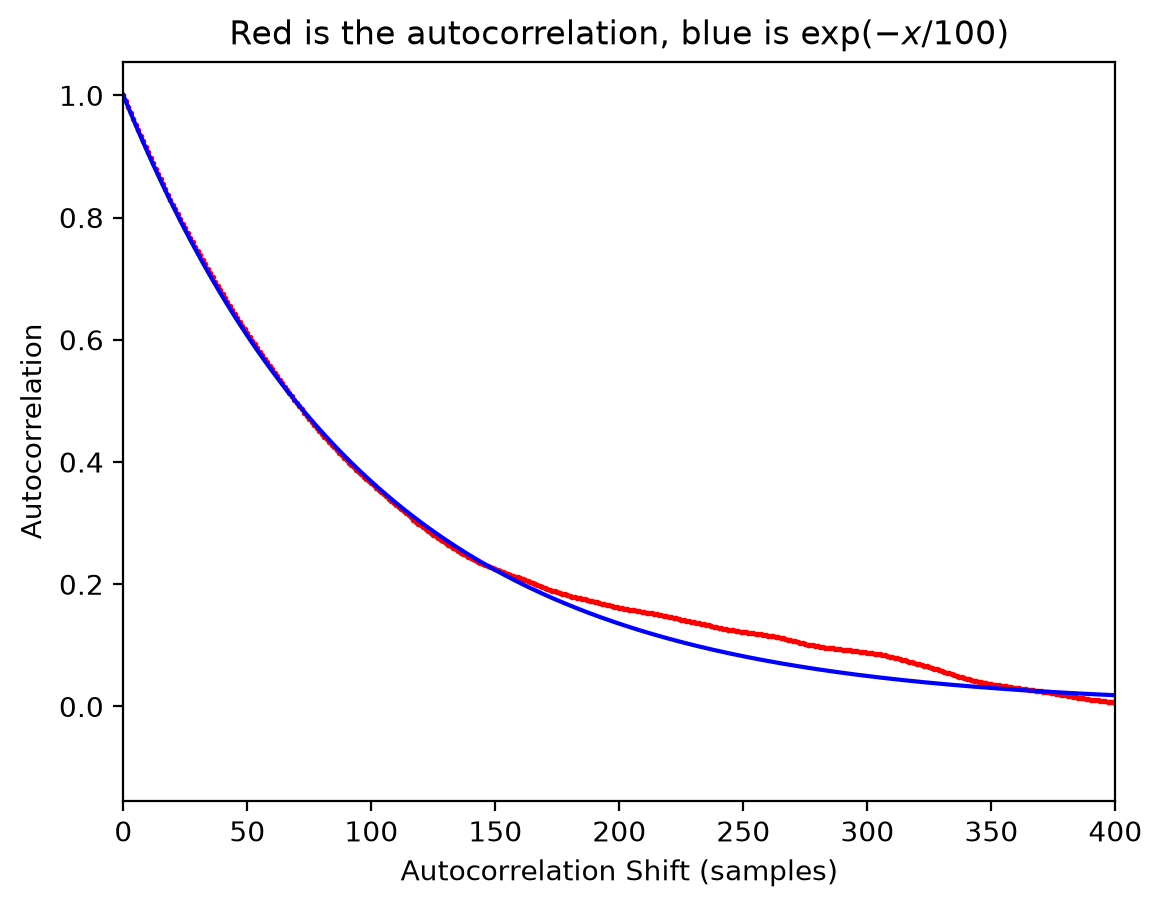

In [5]:
target_length = 100000
correlation_length = 100

x = np.arange(target_length)
y = pyspeckle.create_correlated(target_length, 200, 100, correlation_length, correlation="exponential")

ac = pyspeckle.autocorrelation(y)
plt.plot(x, ac, "ro", markersize=1)
plt.plot(x, np.exp(-x / correlation_length), color="blue")
plt.xlim(0, 4 * correlation_length)

plt.title(r"Red is the autocorrelation, blue is $\exp(-x/%.0f)$" % correlation_length)
plt.xlabel("Autocorrelation Shift (samples)")
plt.ylabel("Autocorrelation")
plt.show()

## Gaussian autocorrelation

`create_correlated` differs only in the shape of the autocorrelation,
$\exp(-x^2/c_l^2)$.  It falls off far more sharply than the exponential at
large lag, so the trace looks smoother on short scales.

For the statistics to match theory the sequence should be much longer than the
correlation length -- a factor of 50 or more.

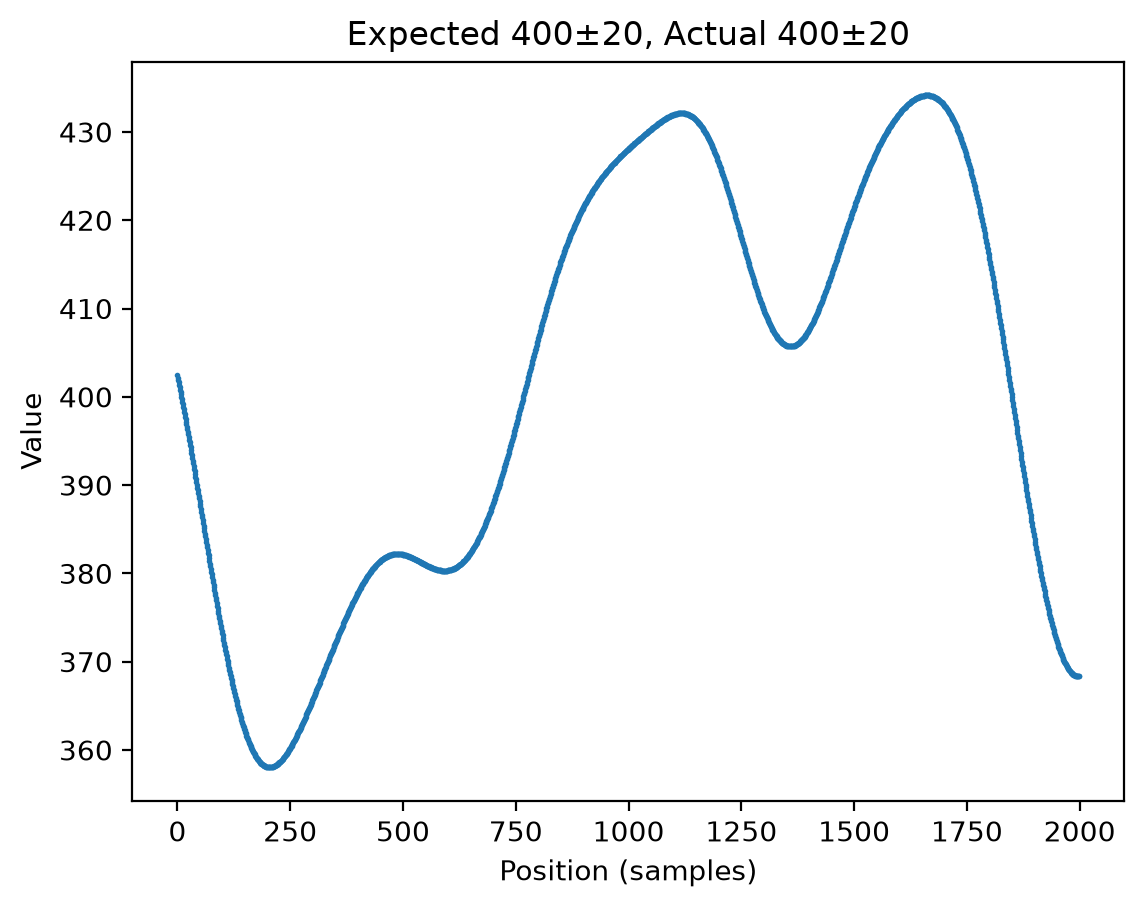

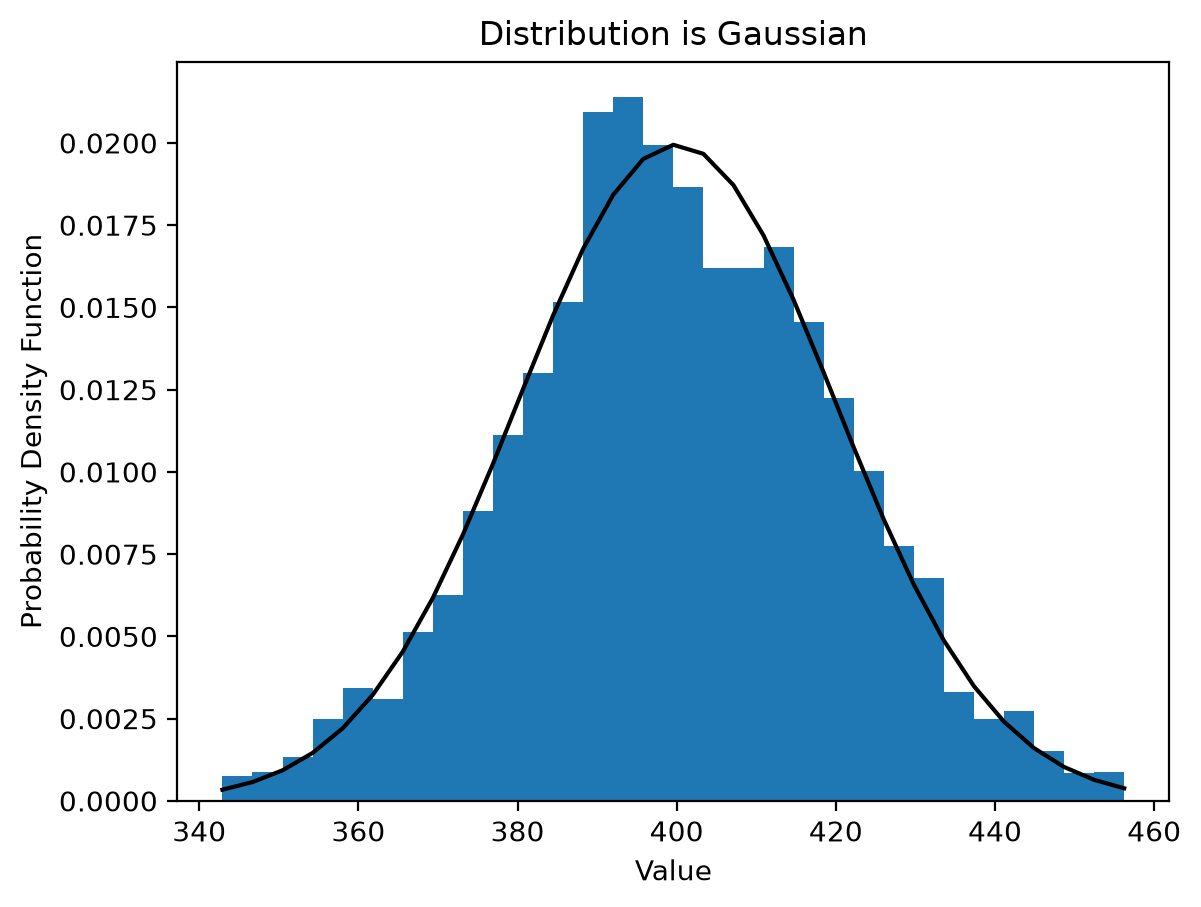

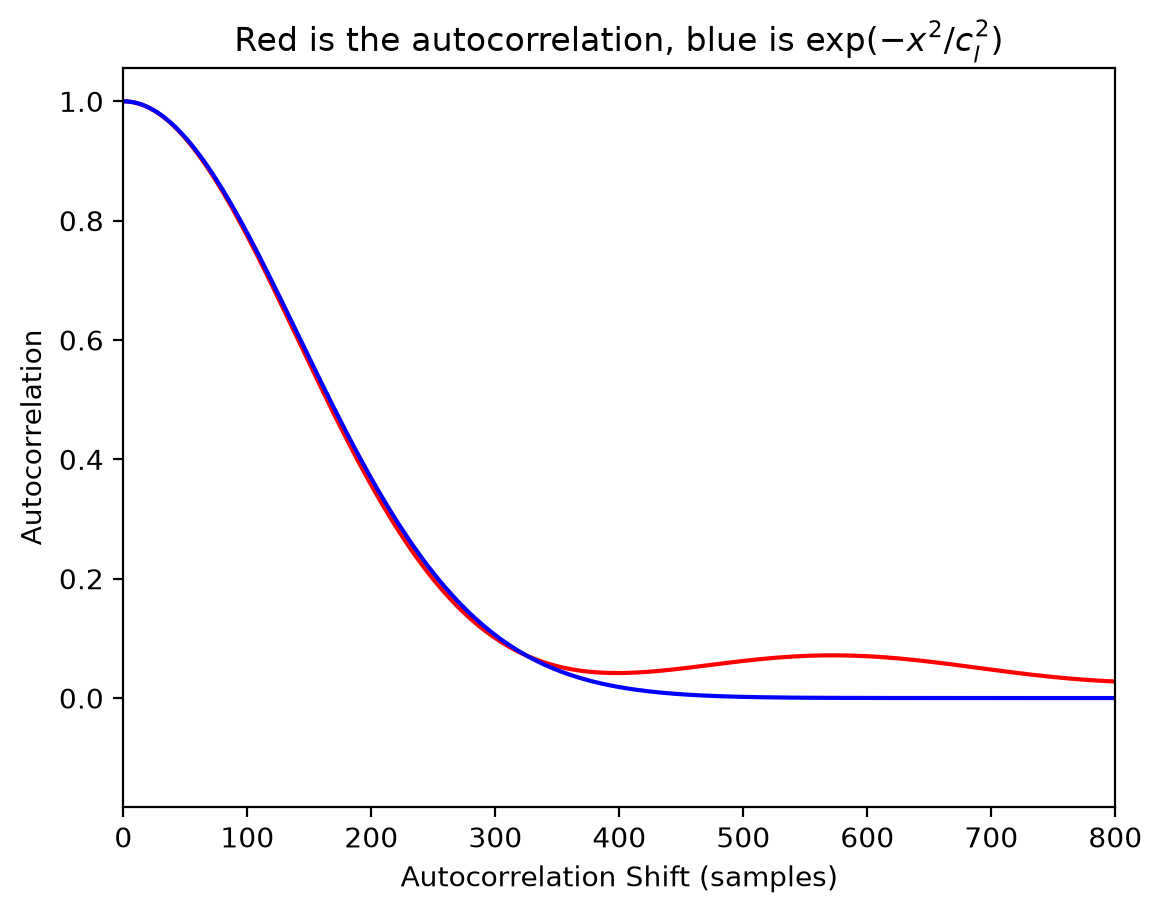

In [6]:
target_length = 100000
target_std = 20
target_ave = 400
correlation_length = 200

x = np.arange(target_length)
y = pyspeckle.create_correlated(target_length, target_ave, target_std, correlation_length)

plt.plot(y[:2000], "o", markersize=1)
plt.title("Expected %.0f±%0.f, Actual %.0f±%0.f" % (target_ave, target_std, np.mean(y), np.std(y)))
plt.xlabel("Position (samples)")
plt.ylabel("Value")
plt.show()

count, bins, ignored = plt.hist(y, 30, density=True)
plt.plot(bins, 1 / (target_std * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((bins - target_ave) / target_std) ** 2), "k")
plt.xlabel("Value")
plt.ylabel("Probability Density Function")
plt.title("Distribution is Gaussian")
plt.show()

ac = pyspeckle.autocorrelation(y)
plt.plot(x, ac, color="red")
plt.plot(x, np.exp(-((x / correlation_length) ** 2)), color="blue")
plt.xlim(0, 4 * correlation_length)
plt.title(r"Red is the autocorrelation, blue is $\exp(-x^2/c_l^2)$")
plt.xlabel("Autocorrelation Shift (samples)")
plt.ylabel("Autocorrelation")
plt.show()

## Summary

Both routines return Gaussian values and differ only in autocorrelation shape.
Neither produces speckle: speckle irradiance is exponentially distributed,
strictly non-negative, and has unit contrast.

To generate actual speckle see the next notebook.  To generate a phase screen
for partially developed speckle, use `pyspeckle.create_phase_screen`, which
is a correlated Gaussian sequence measured in radians.